# Voteview without the server — the panel and the reduction

The counterpart to [`mcp.ipynb`](mcp.ipynb): the same arc, built from the CSV
on disk with nothing in between. The other sources use this notebook to
contrast a vendor HTTP client against the server; Voteview has no client, so
what it contrasts is the **reduction** — the step that turns 51,064 member rows
into eight series.

That is the thing the server hides. Through MCP you ask for
`voteview/median_gap/house` and get 85 numbers. Here you can see where each one
came from.

In [1]:
import sys
sys.path.append("../")     # notebooks/<source>/ helpers
sys.path.append("../../")  # repo root

import statistics
from matplotlib import pyplot

from lib import config
from utils import fetch, voteview_series as vs

pyplot.style.use(config.glyfish_style)

panel = vs.load_panel()
print(f"{sum(len(v) for v in panel.values()):,} scored member-Congress rows")
print(f"{len({c for c, _, _ in panel})} congresses x {len({ch for _, ch, _ in panel})} chambers "
      f"x {len({p for _, _, p in panel})} parties")


50,728 scored member-Congress rows
119 congresses x 2 chambers x 53 parties


## The panel, before anything is reduced

`load_panel` keys on `(congress, chamber, party)` and drops the 129 President
rows and the 224 members with no score. What survives is a bag of DW-NOMINATE
positions per group — no ordering, no time, just members.

In [2]:
for congress, label in ((119, "2025, two even parties"), (17, "1821, one-party rule")):
    groups = sorted(((p, v) for (c, ch, p), v in panel.items()
                     if c == congress and ch == "House"), key=lambda kv: -len(kv[1]))
    total = sum(len(v) for _, v in groups)
    print(f"  {label}: {total} members across {len(groups)} parties")
    for party, values in groups[:3]:
        print(f"    party {party:>4}  n={len(values):3d}  median {statistics.median(values):+.3f}"
              f"  spread {statistics.pstdev(values):.3f}")


  2025, two even parties: 450 members across 3 parties
    party  200  n=227  median +0.530  spread 0.161
    party  100  n=222  median -0.396  spread 0.114
    party  328  n=  1  median +0.151  spread 0.000
  1821, one-party rule: 198 members across 2 parties
    party   13  n=163  median +0.106  spread 0.396
    party    1  n= 35  median +0.360  spread 0.371


## One measure, computed by hand

`party_predicts_position` is the distance between the two largest parties'
medians divided by the average spread *within* them. Doing it in the open shows
why the denominator matters: two parties can be far apart and still predict
nothing, if their own members are scattered further.

In [3]:
congress, chamber = 119, "House"
groups = sorted(((p, v) for (c, ch, p), v in panel.items()
                 if c == congress and ch == chamber), key=lambda kv: -len(kv[1]))
(pa, a), (pb, b) = groups[0], groups[1]

between = abs(statistics.median(a) - statistics.median(b))
within = (statistics.pstdev(a) * len(a) + statistics.pstdev(b) * len(b)) / (len(a) + len(b))

print(f"  party {pa}: n={len(a)}  median {statistics.median(a):+.3f}  sd {statistics.pstdev(a):.3f}")
print(f"  party {pb}: n={len(b)}  median {statistics.median(b):+.3f}  sd {statistics.pstdev(b):.3f}")
print(f"\n  between-party separation  {between:.3f}")
print(f"  within-party spread       {within:.3f}")
print(f"  ratio                     {between / within:.3f}")
print(f"  module agrees             {vs.party_predicts_position(panel, congress, chamber):.3f}")

  party 200: n=227  median +0.530  sd 0.161
  party 100: n=222  median -0.396  sd 0.114

  between-party separation  0.925
  within-party spread       0.138
  ratio                     6.714
  module agrees             6.714


## The gate, which is the part worth understanding

The ratio is confounded with how evenly the chamber is split. A party reduced
to a rump is a *biased survivor* — the members who held the safest seats — not
a random sample of where the party stood. So comparing its median to a
163-member median is not the same measurement.

Below a 25% second party the module returns `None` rather than a number that
would rank alongside the others.

In [4]:
print("  congress  year  2nd party  ratio")
for congress in (15, 17, 19, 23, 80, 119):
    groups = sorted((len(v) for (c, ch, _), v in panel.items()
                     if c == congress and ch == "House"), reverse=True)
    share = groups[1] / sum(groups)
    value = vs.party_predicts_position(panel, congress, "House")
    verdict = f"{value:.2f}" if value is not None else "gated"
    print(f"    {congress:4d}   {vs.congress_year(congress)}    {share:6.0%}    {verdict}")


  congress  year  2nd party  ratio
      15   1817       21%    gated
      17   1821       18%    gated
      19   1825       50%    1.60
      23   1833       28%    2.30
      80   1947       43%    3.01
     119   2025       49%    6.71


1817 and 1821 are the Era of Good Feelings: the Federalists collapse and one
party holds four fifths of the House. There is no second party to measure
against, so the measure declines to answer — which is the honest result, not a
missing one. `effective_parties` covers those Congresses instead.

## Build a series and plot it

The same call the loader makes, then straight to a figure.

  voteview/party_predicts_position/house  110 observations, 1789-2025


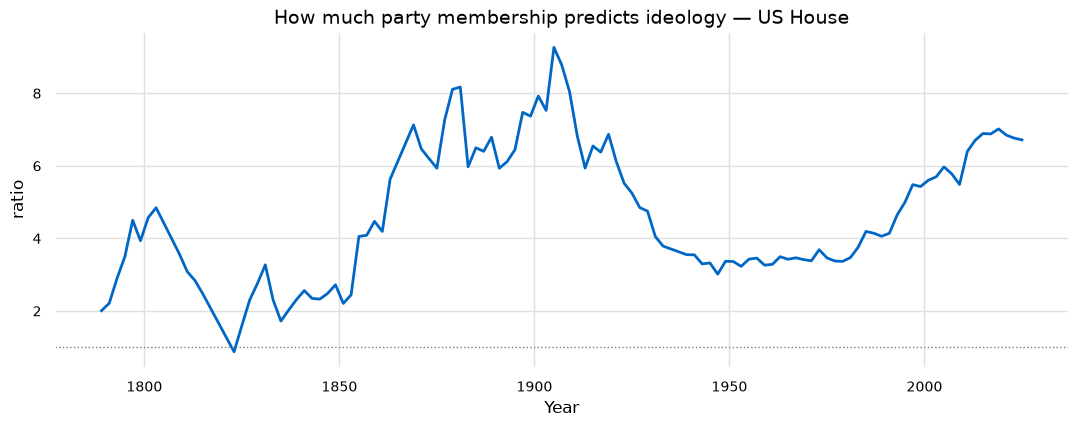

In [5]:
record = vs.build_series("party_predicts_position", "House", scores=panel)
years = [int(o["date"][:4]) for o in record["observations"]]
values = [float(o["value"]) for o in record["observations"]]

print(f"  {record['native_id']}  {record['observation_count']} observations, "
      f"{record['observation_start'][:4]}-{record['observation_end'][:4]}")

fig, ax = pyplot.subplots(figsize=(11, 4.5))
ax.plot(years, values, lw=2)
ax.axhline(1, color="grey", ls=":", lw=1)
ax.set_xlabel("Year"); ax.set_ylabel(record["units"])
ax.set_title(record["title"])
fig.tight_layout()

The gaps in that line are the gated Congresses — the measure is absent, not
zero, and plotting it as a gap rather than a dip is the point of returning
`None`.

Run [`mcp.ipynb`](mcp.ipynb) to get the same series out of Postgres through the
server. The numbers are identical; what differs is that none of the reasoning
above is visible from there.